# EXERCISE 1

## Imports

In [2]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import arff

## Constants

In [3]:
# Base directory
base_dir = "data/ex1_features"

# Song directories
song_dirs = sorted(
    [os.path.join(base_dir, d) for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])

## Read feature files

In [8]:
# Load all songs into a dict
song_data = {}

for song_path in song_dirs:
    song_name = os.path.basename(song_path)
    print(f"Loading {song_name}...")

    # Get all ARFF files
    arff_files = sorted([os.path.join(song_path, f) for f in os.listdir(song_path) if f.endswith(".arff")])

    dfs = []
    for f in arff_files:
        data, meta = arff.loadarff(f)
        df = pd.DataFrame(data)
        #df = df.iloc[:, [0]] # only first column
        dfs.append(df)

    # Merge all windows
    song_df = pd.concat(dfs, ignore_index=True)
    song_df.index.name = "window_number"

    # Decode bytes -> str if necessary
    song_df = song_df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)

    # Convert everything to numeric
    song_df = song_df.apply(pd.to_numeric, errors='coerce')

    if 'WindowNumber' in song_df.columns:
        song_df = song_df.set_index('WindowNumber')

    song_data[song_name] = song_df

Loading classical...
Loading electronic...


/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_25811/251918334.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  song_df = song_df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)
/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_25811/251918334.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  song_df = song_df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


Loading rock...


/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_25811/251918334.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  song_df = song_df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


In [14]:
print(song_data)

{'classical':               Zero-crossing rate  Root mean square  Low energy
WindowNumber                                                  
1.0                     0.000000               NaN         NaN
2.0                     0.019531               NaN         NaN
3.0                     0.043945               NaN         NaN
4.0                     0.005859               NaN         NaN
5.0                     0.025391               NaN         NaN
...                          ...               ...         ...
14716.0                      NaN               NaN        0.59
14717.0                      NaN               NaN        0.59
14718.0                      NaN               NaN        0.59
14719.0                      NaN               NaN        0.59
14720.0                      NaN               NaN        0.59

[44160 rows x 3 columns], 'electronic':               Zero-crossing rate  Root mean square  Low energy
WindowNumber                                                  


## Plot features

1 plot x feature (containing data from the 3 songs

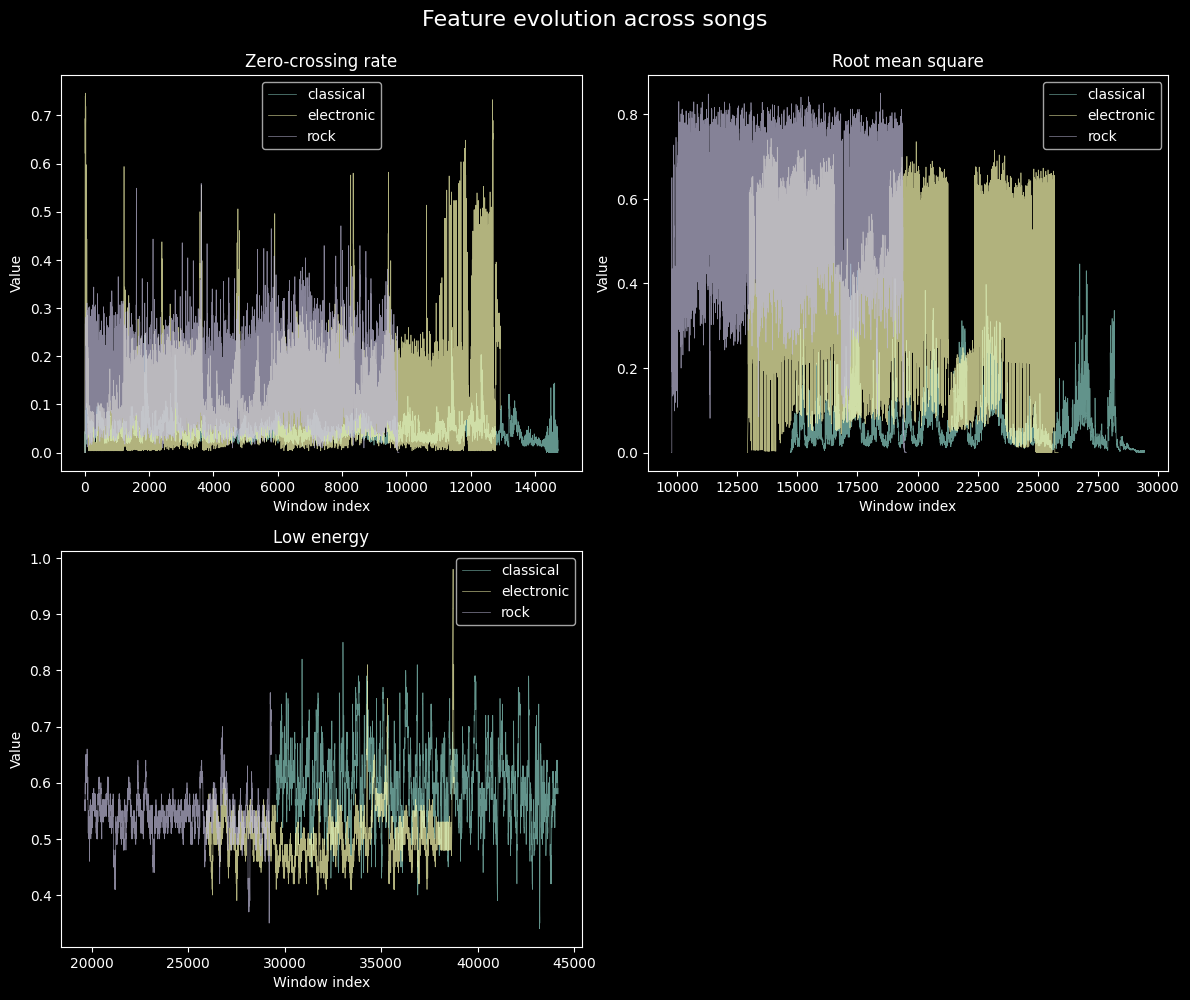

In [13]:
num_features = 3

# Identify feature names (assuming all songs share same structure)
features = list(next(iter(song_data.values())).columns[:num_features])  # first n features

# Plot one figure per feature, with 3 song curves
plt.figure(figsize=(12, 14))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    for song_name, df in song_data.items():
        plt.plot(df[feature].values, label=song_name, alpha=0.7, linewidth=0.5)
    plt.title(feature)
    plt.xlabel("WindowNumber")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()

plt.suptitle("Feature evolution across songs", fontsize=16, y=1.02)
plt.show()